# Creator crossover across tracked titles

**This measures creator crossover, not viewer overlap — read every result
below with that distinction in mind, not as an answer to the brief's
Limitation 1 (multi-homing).** Limitation 1 asks whether the *same
viewers* watch multiple titles. This notebook instead asks whether the
*same streamers* broadcast multiple titles at an above-threshold audience
size. Those are related but not the same question: a streamer switching
between two games says their own following is willing to watch them play
either — informative, but it's a proxy for creator supply, not viewer
demand. It's one inferential step removed from what Limitation 1 actually
asks, not a direct measurement of it.

**Method:** `viewership_snapshots` classifies every captured stream as
either `is_official_broadcast=1` (a curated official channel,
`config/channels.yaml`) or `0` (captured because it crossed the
above-threshold viewer-count cutoff — "tier 2" in `collectors/
twitch_poll.py`'s own capture-tier language; tier 3, below threshold, is
never captured per-stream at all). This notebook looks only at tier-2
(`is_official_broadcast=0`) rows: does a given `channel_id` appear as an
above-threshold streamer for more than one tracked title, and if so, how
is its above-threshold viewer-time split between them. `config/
channels.yaml` now has 5 titles curated (counter_strike, dota2,
street_fighter, valorant, pubg) — the official-channel filter is doing
real exclusion work for those five, still a no-op for the other 18 until
they're curated too. Worth remembering when reading any of those five
titles' numbers below: their crossover pools now exclude official
broadcast channels, while every other title's pool still includes them.

**This covers the full history captured since the Twitch collector
started (2026-08-31) through 2026-10-02 — about five weeks as of this
run**, re-run from an earlier pass that only had ~15 days. Still a
relatively short window against the collector's eventual lifetime, not a
settled base rate — read today's output as directional and expect
individual pair ratios, especially for smaller-pool titles, to keep
moving as more data accumulates. The September 15 pass already reversed
on at least one headline pair once given three more weeks of data (see
`§ What the chance-adjustment actually changed` below) — a concrete
demonstration of that instability, not just a caveat.

In [1]:
# Imports and repo path setup — same pattern as the other notebooks.
import sys
from itertools import combinations
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import yaml
from scipy.stats import hypergeom

from etl.db import get_connection

In [2]:
# All 23 active titles — config/titles.yaml is the source of truth, same
# as every other notebook in this project.
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]

active_titles = [t for t in titles_config if t.get("is_active")]
display_name_by_id = {t["id"]: t["display_name"] for t in active_titles}
len(active_titles)

23

## Load tier-2 (above-threshold, non-official) stream records

One row per full-detail stream per poll. `viewer_count` summed per
`(channel_id, title_id)` gives a viewer-time figure, same convention used
in `research/foundations/fandom_and_niche_model/notebooks/niche_membership.ipynb`'s language-mix analysis — weighted
by how long and how big the stream was, not just by poll count.

In [3]:
conn = get_connection()
window_start, window_end = conn.execute(
    "SELECT MIN(captured_at), MAX(captured_at) FROM viewership_snapshots"
).fetchone()
print(f"viewership_snapshots window: {window_start} to {window_end}")

raw_rows = conn.execute(
    """
    SELECT channel_id, channel_login, title_id, viewer_count
    FROM viewership_snapshots
    WHERE is_official_broadcast = 0
    """
).fetchall()
conn.close()

raw_df = pd.DataFrame(raw_rows, columns=["channel_id", "channel_login", "title_id", "viewer_count"])

# Login for display only, kept separate from the aggregation below — a
# channel_login can change mid-window if a streamer renames, and grouping
# by it directly would silently split one channel's viewer-time across
# what looks like two different rows. channel_id is the only real join key.
login_by_channel = raw_df.groupby("channel_id")["channel_login"].agg(lambda s: s.mode().iat[0])

channel_title_df = (
    raw_df.groupby(["channel_id", "title_id"])["viewer_count"].sum().rename("viewer_time").reset_index()
)

print(f"{channel_title_df['channel_id'].nunique()} distinct above-threshold, non-official channels seen")
print(f"{len(channel_title_df)} (channel, title) combinations total")

viewership_snapshots window: 2026-08-31T10:13:48Z to 2026-10-02T12:18:26Z


296583 distinct above-threshold, non-official channels seen
335823 (channel, title) combinations total


## Crossover channels

A channel counts as crossover if it appears above-threshold for more
than one tracked title anywhere in the window — no minimum viewer-time
cutoff at this stage, so this first count includes channels that barely
crossed the threshold once for a second title. The per-channel table
below carries actual viewer-time so a marginal crossover is visibly
marginal, not hidden.

In [4]:
titles_per_channel = channel_title_df.groupby("channel_id")["title_id"].nunique()
crossover_channel_ids = titles_per_channel[titles_per_channel > 1].index

crossover_df = channel_title_df[channel_title_df["channel_id"].isin(crossover_channel_ids)].copy()
crossover_df["channel_login"] = crossover_df["channel_id"].map(login_by_channel)
crossover_df["display_name"] = crossover_df["title_id"].map(display_name_by_id)

channel_totals = crossover_df.groupby("channel_id")["viewer_time"].sum()
crossover_df["share_of_channel_viewer_time_pct"] = (
    crossover_df["viewer_time"] / crossover_df["channel_id"].map(channel_totals) * 100
).round(1)

print(f"{len(crossover_channel_ids)} channels (of {channel_title_df['channel_id'].nunique()} total) "
      f"streamed above-threshold for more than one title this window.")
print("\nDistribution of how many titles a crossover channel touched:")
print(titles_per_channel[titles_per_channel > 1].value_counts().sort_index())

33232 channels (of 296583 total) streamed above-threshold for more than one title this window.

Distribution of how many titles a crossover channel touched:
title_id
2    28122
3     4346
4      645
5      106
6       11
7        2
Name: count, dtype: int64


## Per-channel breakdown, top 30 by total above-threshold viewer-time

Long format (one row per channel × title), not a wide pivot — most
crossover channels only touch 2 of 23 titles, so a full title-by-title
grid would be almost entirely empty. Sorted by each channel's total
viewer-time across all its titles, so the crossover activity that
actually moved meaningful audience shows up first, ahead of channels that
crossed the threshold once for a handful of viewers.

In [5]:
TOP_N_CHANNELS = 30

top_channel_ids = channel_totals.sort_values(ascending=False).head(TOP_N_CHANNELS).index

top_display = (
    crossover_df[crossover_df["channel_id"].isin(top_channel_ids)]
    .assign(channel_total_viewer_time=lambda d: d["channel_id"].map(channel_totals))
    .sort_values(["channel_total_viewer_time", "channel_id", "viewer_time"], ascending=[False, True, False])
    [["channel_login", "display_name", "viewer_time", "share_of_channel_viewer_time_pct", "channel_total_viewer_time"]]
    .rename(columns={"display_name": "title"})
    .reset_index(drop=True)
)
top_display

,channel_login,title,viewer_time,share_of_channel_viewer_time_pct,channel_total_viewer_time
0,caedrel,League of Legends,2240224,97.2,2305222
1,caedrel,Rocket League,46780,2.0,2305222
2,caedrel,VALORANT,18218,0.8,2305222
3,jynxzi,Rainbow Six Siege,810877,53.7,1509205
4,jynxzi,Fortnite,339453,22.5,1509205
...,...,...,...,...,...
75,mooda,League of Legends,49251,46.4,106229
76,mooda,Fortnite,4453,4.2,106229
77,sasavot,Dota 2,44582,42.9,103882
78,sasavot,Counter-Strike 2,37742,36.3,103882


## Which title pairs share the most crossover channels — and in which direction

A raw shared-channel count doesn't say much on its own: 462 channels
shared between League of Legends and VALORANT means something different
depending on whether that's 462 out of League's ~11,600 above-threshold
channels or 462 out of a much smaller pool. Four numbers per pair instead
of one, **shown as two directions side by side, not averaged into a
single score** — the asymmetry itself is the finding, the same shape as
League/Teamfight Tactics (a large fraction of TFT's creator base also
streams League, since they share Riot's client/audience, but only a
small fraction of League's much larger creator base also streams TFT):

- `channel_overlap_pct_a_to_b` — of all channels that streamed **A**
  above-threshold this window, what percent also streamed **B**.
- `channel_overlap_pct_b_to_a` — the reverse: of B's channels, what
  percent also streamed A.
- `viewer_time_overlap_pct_a_to_b` — of **A**'s total above-threshold
  viewer-time, what percent came from channels that also streamed B (not
  the same as the channel-count version above: a handful of big crossover
  channels can carry a large viewer-time share while being a small
  fraction of A's channel count, or the reverse).
- `viewer_time_overlap_pct_b_to_a` — the reverse.

`total_channels_a`/`total_channels_b` (the denominators) are kept visible
in the table, not folded into the percentages — a ratio without its
denominator invites over-reading a small, noisy sample as a strong
signal.

**Chance-adjusted enrichment is the primary "is this unusual" read below,
not the flat baseline.** The flat baseline (~11% of channels cross over
to *something*) is kept further down for context, but it's a weak
comparison — two huge titles will rack up a big raw overlap purely from
both having enormous channel pools, with no real affinity implied. The
real question is whether a pair's overlap exceeds what two titles of
*their specific sizes* would share by pure chance:

- `expected_shared = total_channels_a * total_channels_b / total_channels`
  — the overlap two titles this size would share if channel selection
  were independent (i.e. a streamer's choice to cross into B has nothing
  to do with whether they already stream A).
- `enrichment_ratio = shared_crossover_channels / expected_shared` — below
  1 means less overlap than chance would predict (suppressed); above 1
  means more (elevated). This is the primary sort key below, not raw
  shared count.
- `hypergeometric_p_value` — an actual significance test
  (`scipy.stats.hypergeom`), not just eyeballing the ratio: the
  probability of seeing overlap this extreme (in whichever direction it
  actually went) if channels crossed into each title independently.
  Several of these pairs have small enough channel counts that a ratio
  alone doesn't say whether it's a real effect or noise — this does.

**Same caveat as before, extended to this metric:** Mobile Legends: Bang
Bang, Free Fire, PUBG Mobile, and Wild Rift — already flagged in
`research/foundations/fandom_and_niche_model/notebooks/niche_membership.ipynb` for thin Twitch-specific viewer-time
samples — are carried over as the flagged set here too. With five more
weeks of data they're no longer literally the four smallest pools by
channel count (1,418, 424, 920, and 766 respectively, against a median
of 4,397 across all 23 now) — Mortal Kombat 1 (584), Guilty Gear -Strive-
(689), and StarCraft II (758) have since dropped smaller without being
flagged, since the original concern was thin *viewer-time*, not channel
count specifically, and that hasn't been re-checked here. Any pair
involving one of the flagged four is still marked
`low_channel_count_flag=True` rather than dropped — the ratio is still
shown, just not to be read as stable yet.

In [6]:
# Global baseline, printed here too (not just where it was first computed
# above) so it's visible right next to the table it's meant to contextualize
# — kept as secondary context, not the primary "is this unusual" read
# (that's the enrichment ratio below).
n_crossover = len(crossover_channel_ids)
n_total_channels = channel_title_df["channel_id"].nunique()
print(
    f"Flat baseline (secondary context): {n_crossover} of {n_total_channels} channels "
    f"({n_crossover / n_total_channels * 100:.1f}%) crossed over to some second title at all this window."
)

# Denominators computed from the FULL channel_title_df (every channel that
# streamed a title above-threshold, not just the crossover subset) --
# these are "all of A's creators," not "A's crossover creators."
total_channels_by_title = channel_title_df.groupby("title_id")["channel_id"].nunique()
total_viewer_time_by_title = channel_title_df.groupby("title_id")["viewer_time"].sum()

# Titles already flagged for a thin above-threshold creator base
# (research/foundations/fandom_and_niche_model/notebooks/niche_membership.ipynb flagged these four for thin
# viewer-time samples; they also have the smallest channel counts here).
LOW_CHANNEL_COUNT_TITLES = {"mobile_legends_bb", "free_fire", "pubg_mobile", "wild_rift"}


def hypergeom_pvalue(shared: int, total_a: int, total_b: int, population: int) -> float:
    """One-sided p-value in whichever direction the overlap actually went.
    Model: population channels total; total_a of them stream A; draw
    total_b of them (the channels that stream B) at random -- what's the
    chance of seeing an overlap at least this extreme? Symmetric in a/b
    (the hypergeometric overlap distribution doesn't care which title is
    "the population subset" vs. "the draw"), so no ordering choice to get
    wrong here."""
    dist = hypergeom(population, total_a, total_b)
    expected = total_a * total_b / population
    if shared >= expected:
        return float(dist.sf(shared - 1))  # P(X >= shared)
    return float(dist.cdf(shared))  # P(X <= shared)


# channel_id -> set of titles it crossed over on, then expanded into a
# channel-set PER PAIR (needed for the viewer-time-weighted ratios, not
# just a count).
titles_by_channel = crossover_df.groupby("channel_id")["title_id"].apply(set)
pair_channels: dict[tuple[str, str], set] = {}
for channel_id, title_set in titles_by_channel.items():
    for a, b in combinations(sorted(title_set), 2):
        pair_channels.setdefault((a, b), set()).add(channel_id)

pair_rows = []
for (a, b), shared_channel_ids in pair_channels.items():
    shared_channels = len(shared_channel_ids)
    total_a, total_b = total_channels_by_title[a], total_channels_by_title[b]

    shared_vt_a = channel_title_df[
        (channel_title_df["title_id"] == a) & (channel_title_df["channel_id"].isin(shared_channel_ids))
    ]["viewer_time"].sum()
    shared_vt_b = channel_title_df[
        (channel_title_df["title_id"] == b) & (channel_title_df["channel_id"].isin(shared_channel_ids))
    ]["viewer_time"].sum()

    expected_shared = total_a * total_b / n_total_channels

    pair_rows.append({
        "title_a": display_name_by_id[a],
        "title_b": display_name_by_id[b],
        "shared_crossover_channels": shared_channels,
        "total_channels_a": total_a,
        "total_channels_b": total_b,
        "channel_overlap_pct_a_to_b": round(shared_channels / total_a * 100, 1),
        "channel_overlap_pct_b_to_a": round(shared_channels / total_b * 100, 1),
        "viewer_time_overlap_pct_a_to_b": round(shared_vt_a / total_viewer_time_by_title[a] * 100, 1),
        "viewer_time_overlap_pct_b_to_a": round(shared_vt_b / total_viewer_time_by_title[b] * 100, 1),
        "expected_shared": round(expected_shared, 1),
        "enrichment_ratio": round(shared_channels / expected_shared, 2) if expected_shared > 0 else float("nan"),
        "hypergeometric_p_value": hypergeom_pvalue(shared_channels, total_a, total_b, n_total_channels),
        "low_channel_count_flag": a in LOW_CHANNEL_COUNT_TITLES or b in LOW_CHANNEL_COUNT_TITLES,
    })

pair_rollup = pd.DataFrame(pair_rows)

# Re-sorted by enrichment_ratio (the chance-adjusted read), not raw
# shared count -- and rank_change shows exactly how much each pair moved
# between the two orderings, so "which pairs move meaningfully" is a
# concrete, visible column, not an eyeballed claim.
pair_rollup["rank_by_shared_count"] = pair_rollup["shared_crossover_channels"].rank(ascending=False, method="min").astype(int)
pair_rollup = pair_rollup.sort_values("enrichment_ratio", ascending=False).reset_index(drop=True)
pair_rollup["rank_by_enrichment"] = pair_rollup.index + 1
pair_rollup["rank_change"] = pair_rollup["rank_by_shared_count"] - pair_rollup["rank_by_enrichment"]

# "Moved meaningfully": top 10 by absolute rank change, not an arbitrary
# fixed cutoff -- self-relative to this run's own distribution of movement.
notable_cutoff = pair_rollup["rank_change"].abs().sort_values(ascending=False).iloc[min(9, len(pair_rollup) - 1)]
pair_rollup["moved_significantly"] = pair_rollup["rank_change"].abs() >= notable_cutoff

n_bonferroni_sig = (pair_rollup["hypergeometric_p_value"] < 0.05 / len(pair_rollup)).sum()
n_raw_sig = (pair_rollup["hypergeometric_p_value"] < 0.05).sum()
print(f"\n{len(pair_rollup)} title pairs share at least one crossover channel")
print(f"{pair_rollup['low_channel_count_flag'].sum()} of those pairs involve a low-channel-count title — flagged, not dropped")
print(
    f"{n_raw_sig} pairs at raw p<0.05 ({len(pair_rollup)} simultaneous tests -- expect ~{0.05*len(pair_rollup):.0f} "
    f"false positives at that threshold by chance alone); {n_bonferroni_sig} survive a Bonferroni-corrected "
    f"threshold (p < {0.05/len(pair_rollup):.5f})"
)

pair_rollup.head(20)

Flat baseline (secondary context): 33232 of 296583 channels (11.2%) crossed over to some second title at all this window.



209 title pairs share at least one crossover channel
53 of those pairs involve a low-channel-count title — flagged, not dropped
193 pairs at raw p<0.05 (209 simultaneous tests -- expect ~10 false positives at that threshold by chance alone); 171 survive a Bonferroni-corrected threshold (p < 0.00024)


,title_a,title_b,shared_crossover_channels,total_channels_a,total_channels_b,channel_overlap_pct_a_to_b,channel_overlap_pct_b_to_a,viewer_time_overlap_pct_a_to_b,viewer_time_overlap_pct_b_to_a,expected_shared,enrichment_ratio,hypergeometric_p_value,low_channel_count_flag,rank_by_shared_count,rank_by_enrichment,rank_change,moved_significantly
0,Guilty Gear -Strive-,Street Fighter 6,56,689,4397,8.1,1.3,22.8,1.1,10.2,5.48,3.436906e-24,False,68,1,67,False
1,Age of Empires II,StarCraft II,11,841,758,1.3,1.5,1.7,2.7,2.1,5.12,1.465788e-05,False,127,2,125,False
2,Guilty Gear -Strive-,Tekken 8,35,689,3007,5.1,1.2,17.5,2.0,7.0,5.01,1.949523e-14,False,77,3,74,False
3,Mortal Kombat 1,Tekken 8,26,584,3007,4.5,0.9,29.2,0.6,5.9,4.39,6.849911e-10,False,86,4,82,False
4,Mobile Legends: Bang Bang,League of Legends: Wild Rift,12,1418,766,0.8,1.6,0.1,1.7,3.7,3.28,4.032384e-04,True,120,5,115,False
5,Street Fighter 6,Tekken 8,132,4397,3007,3.0,4.4,6.4,12.3,44.6,2.96,3.193315e-27,False,47,6,41,False
6,Free Fire,Mobile Legends: Bang Bang,6,424,1418,1.4,0.4,1.2,0.1,2.0,2.96,1.721929e-02,True,155,7,148,True
7,Free Fire,League of Legends: Wild Rift,3,424,766,0.7,0.4,0.1,0.0,1.1,2.74,9.823100e-02,True,172,8,164,True
8,Mobile Legends: Bang Bang,PUBG Mobile,12,1418,920,0.8,1.3,0.4,0.3,4.4,2.73,1.908474e-03,True,120,9,111,False
9,League of Legends,Teamfight Tactics,1960,38518,6025,5.1,32.5,4.7,14.9,782.5,2.50,0.000000e+00,False,6,10,-4,False


### What the chance-adjustment actually changed

**Updated 2026-10-02, re-run with five weeks of data instead of two —
one of these two findings reversed outright, not just drifted:**

- **League of Legends/Teamfight Tactics has flipped from "almost exactly
  at chance" to one of the stronger enriched pairs in the whole
  dataset.** The 2026-09-15 pass (15 days of data) found
  `enrichment_ratio=0.96`, `p=0.26` — framed at the time as the key
  lesson in why chance-adjustment matters, since the raw 298-shared-
  channel, 13.1%-TFT→League numbers looked disproportionate but weren't,
  once pool size was accounted for. With three more weeks of data:
  `enrichment_ratio=2.50`, `shared_crossover_channels=1960` (up from
  298), and the hypergeometric p-value underflows double precision
  (far below 1e-300 — not a computation error, just how extreme the tail
  probability is at this sample size). The directional asymmetry is
  still there and, if anything, sharper: 32.5% of TFT's channels also
  stream League (`channel_overlap_pct_b_to_a`), against 5.1% the other
  way. **Read this as the window being genuinely too short in the
  09-15 pass, not as the chance-adjustment method being unreliable** — a
  782-expected-overlap pair settling at 1960 actual once given enough
  time to resolve is exactly the kind of signal chance-adjustment is
  built to confirm, it just needed more data to get there. Don't treat
  today's 2.50x as final either; re-check again once the window is
  longer still.
- **Most large-pool pairs still show significant *suppression*, not
  enrichment** — Rainbow Six/Rocket League, Counter-Strike/PUBG,
  Counter-Strike/Dota 2, Teamfight Tactics/VALORANT, and Dota 2/PUBG all
  still land at enrichment well under 1. Read this cautiously, not as
  "these titles' fans actively avoid each other": the independence null
  assumes any channel is equally likely to stream any title, but the
  flat baseline above already shows 88.8% of channels never cross over
  to a second title *at all* — most streamers only stream one game,
  structurally, which mechanically depletes overlap between any two
  large pools relative to a model that doesn't account for that. The
  handful of *elevated* pairs are more informative for exactly this
  reason — they're beating a baseline that's already working against
  crossover happening at all. The strongest of these is no longer
  Age of Empires II/StarCraft II (5.12x now, still real and still
  significant) — it's been overtaken by Guilty Gear -Strive-/Street
  Fighter 6 at 5.48x, see `§ Enrichment ratio, as a clustered heatmap`
  below for the fuller picture of how much the fighting-game cluster
  moved.

In [7]:
# The pairs the enrichment-based sort actually changed the story for —
# biggest absolute rank movement between "raw shared count" and
# "chance-adjusted enrichment," shown directly rather than left to be
# spotted by comparing two full 141-row tables by eye.
movers = (
    pair_rollup[pair_rollup["moved_significantly"]]
    .sort_values("rank_change", key=lambda s: s.abs(), ascending=False)
    [["title_a", "title_b", "shared_crossover_channels", "rank_by_shared_count",
      "rank_by_enrichment", "rank_change", "enrichment_ratio", "hypergeometric_p_value"]]
    .reset_index(drop=True)
)
movers

,title_a,title_b,shared_crossover_channels,rank_by_shared_count,rank_by_enrichment,rank_change,enrichment_ratio,hypergeometric_p_value
0,Mortal Kombat 1,League of Legends: Wild Rift,1,195,27,168,0.66,0.554656
1,Guilty Gear -Strive-,Mortal Kombat 1,2,180,14,166,1.47,0.393397
2,Free Fire,League of Legends: Wild Rift,3,172,8,164,2.74,0.098231
3,Mortal Kombat 1,PUBG Mobile,1,195,33,162,0.55,0.458795
4,PUBG Mobile,League of Legends: Wild Rift,2,180,23,157,0.84,0.575677
5,Free Fire,Mobile Legends: Bang Bang,6,155,7,148,2.96,0.017219
6,Brawl Stars,Free Fire,5,157,12,145,2.02,0.105295
7,Age of Empires II,Hearthstone,4,165,26,139,0.75,0.382067
8,Dota 2,Fortnite,110,50,189,-139,0.04,0.000000
9,Brawl Stars,PUBG Mobile,5,157,19,138,0.93,0.549495


## Enrichment ratio, as a clustered heatmap

Requested directly by the user (2026-09-09): the pair-by-pair table above
answers "which pairs" but not "what does the whole 23-title structure
look like at a glance." Same `enrichment_ratio` data, reshaped into a
full title × title matrix and hierarchically clustered — titles whose
whole *pattern* of enrichment with every other title looks similar
(not just any single pair) end up adjacent, which is what actually
reveals sub-groups (e.g. a battle-royale cluster, a MOBA-adjacent
cluster) rather than one pair at a time.

In [8]:
import matplotlib.pyplot as plt
import numpy as np

titles = [t["id"] for t in active_titles]
names = [display_name_by_id[t] for t in titles]
n = len(titles)

enrichment_matrix = pd.DataFrame(0.0, index=names, columns=names)
for _, row in pair_rollup.iterrows():
    a, b, ratio = row["title_a"], row["title_b"], row["enrichment_ratio"]
    if pd.isna(ratio):
        continue
    enrichment_matrix.loc[a, b] = ratio
    enrichment_matrix.loc[b, a] = ratio

total_possible_pairs = n * (n - 1) // 2
n_zero_pairs = total_possible_pairs - len(pair_rollup)
print(
    f"{n_zero_pairs} of {total_possible_pairs} possible title pairs had zero shared "
    f"crossover channels this window -- filled as enrichment_ratio=0.0 (a real "
    f"result: zero overlap where some was expected by chance), not 'not computed'."
)

# Diagonal (a title against itself) is undefined -- there's no meaningful
# "enrichment of A's crossover with A." Filled with 1.0 (the chance
# baseline) only so it doesn't distort the clustering below with an
# arbitrary extreme value; every chart in this section treats the
# diagonal as not meaningful, not a real result.
for name in names:
    enrichment_matrix.loc[name, name] = 1.0
enrichment_matrix.round(2)

44 of 253 possible title pairs had zero shared crossover channels this window -- filled as enrichment_ratio=0.0 (a real result: zero overlap where some was expected by chance), not 'not computed'.


,League of Legends,Dota 2,Counter-Strike 2,StarCraft II,Hearthstone,Rocket League,Rainbow Six Siege,Overwatch,Tekken 8,Street Fighter 6,...,Apex Legends,Fortnite,PUBG: BATTLEGROUNDS,PUBG Mobile,Free Fire,Mobile Legends: Bang Bang,League of Legends: Wild Rift,Teamfight Tactics,Brawl Stars,Age of Empires II
League of Legends,1.00,0.08,0.30,0.35,0.45,0.18,0.14,0.32,0.16,0.19,...,0.24,0.13,0.25,0.03,0.07,0.12,0.54,2.50,0.06,0.40
Dota 2,0.08,1.00,0.92,0.58,1.02,0.02,0.02,0.05,0.07,0.03,...,0.09,0.04,0.96,0.09,0.10,0.31,0.03,0.11,0.15,0.21
Counter-Strike 2,0.30,0.92,1.00,0.20,0.38,0.28,0.20,0.14,0.11,0.05,...,0.16,0.12,0.92,0.39,0.05,0.31,0.07,0.36,0.14,0.23
StarCraft II,0.35,0.58,0.20,1.00,2.29,0.07,0.02,0.19,0.52,0.18,...,0.10,0.10,0.16,0.00,0.00,0.00,0.00,0.45,0.23,5.12
Hearthstone,0.45,1.02,0.38,2.29,1.00,0.21,0.07,0.33,0.42,0.04,...,0.08,0.08,0.33,0.00,0.00,0.33,0.21,1.05,0.00,0.75
Rocket League,0.18,0.02,0.28,0.07,0.21,1.00,0.61,0.22,0.12,0.04,...,0.21,0.46,0.18,0.04,0.30,0.06,0.02,0.23,0.34,0.22
Rainbow Six Siege,0.14,0.02,0.20,0.02,0.07,0.61,1.00,0.28,0.13,0.10,...,0.30,0.26,0.25,0.04,0.00,0.04,0.00,0.10,0.09,0.04
Overwatch,0.32,0.05,0.14,0.19,0.33,0.22,0.28,1.00,0.26,0.37,...,0.50,0.28,0.11,0.02,0.00,0.07,0.03,0.40,0.06,0.18
Tekken 8,0.16,0.07,0.11,0.52,0.42,0.12,0.13,0.26,1.00,2.96,...,0.21,0.15,0.04,0.21,0.00,0.28,0.00,0.18,0.00,0.23
Street Fighter 6,0.19,0.03,0.05,0.18,0.04,0.04,0.10,0.37,2.96,1.00,...,0.77,0.06,0.18,0.00,0.00,0.00,0.00,0.29,0.00,0.16


### Clustering the matrix

Rows and columns share one clustering (they're the same 23 titles), so
one linkage computed once and reused for both charts below — average-
linkage hierarchical clustering on each title's full 23-value enrichment
profile (Euclidean distance between rows), with **optimal leaf
ordering** (`scipy.cluster.hierarchy.linkage(..., optimal_ordering=True)`):
this is what pulls high-enrichment titles toward one corner as a side
effect of grouping similar titles together, without forcing a strict
sort that would ignore the actual cluster structure.

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(enrichment_matrix.values, method="average", metric="euclidean", optimal_ordering=True)
leaf_order = dendrogram(linkage_matrix, no_plot=True)["leaves"]
ordered_names = [names[i] for i in leaf_order]
ordered_matrix = enrichment_matrix.loc[ordered_names, ordered_names]

print("Leaf order (top-left to bottom-right):")
for i, name in enumerate(ordered_names):
    print(f"  {i+1:2d}. {name}")

Leaf order (top-left to bottom-right):
   1. StarCraft II
   2. Age of Empires II
   3. Teamfight Tactics
   4. League of Legends
   5. Hearthstone
   6. Dota 2
   7. Counter-Strike 2
   8. PUBG: BATTLEGROUNDS
   9. VALORANT
  10. Overwatch
  11. Apex Legends
  12. Rainbow Six Siege
  13. Rocket League
  14. Fortnite
  15. Brawl Stars
  16. League of Legends: Wild Rift
  17. PUBG Mobile
  18. Free Fire
  19. Mobile Legends: Bang Bang
  20. Guilty Gear -Strive-
  21. Mortal Kombat 1
  22. Street Fighter 6
  23. Tekken 8


### Plain matplotlib version

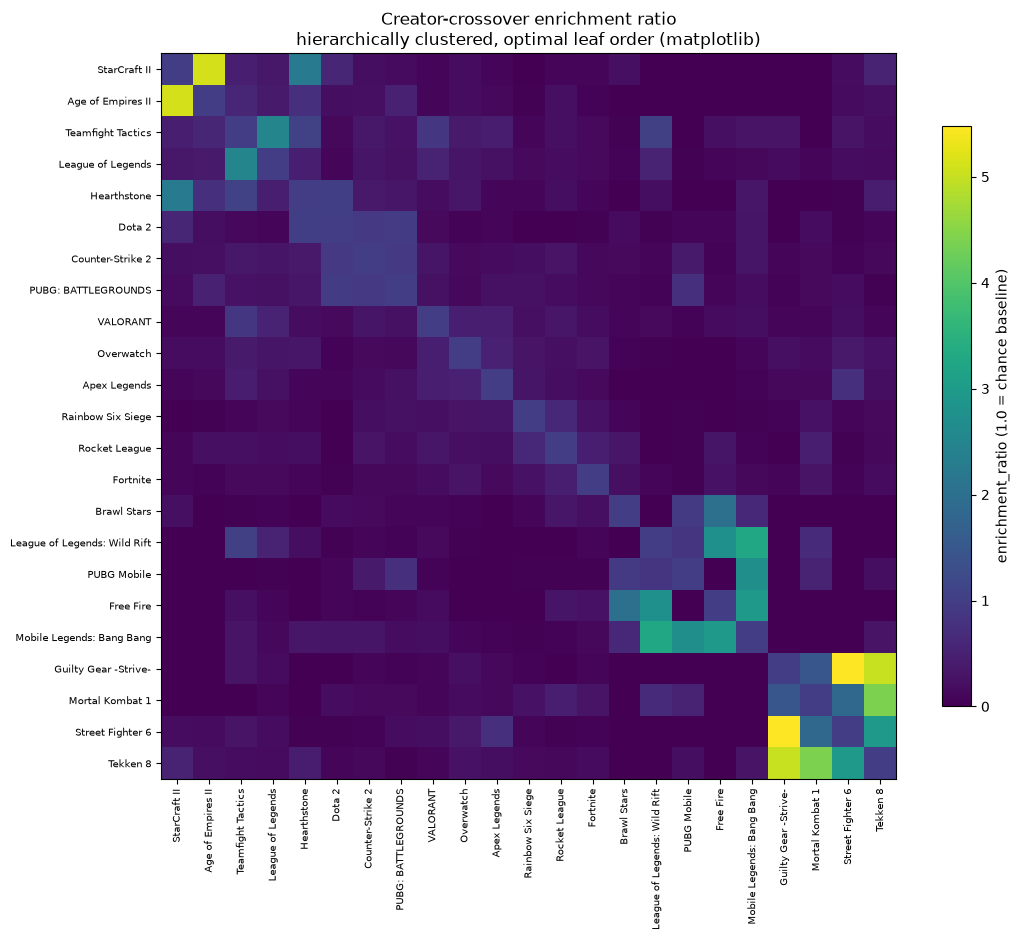

In [10]:
fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(ordered_matrix.values, cmap="viridis", aspect="auto", vmin=0)
ax.set_xticks(range(n))
ax.set_xticklabels(ordered_matrix.columns, rotation=90, fontsize=7)
ax.set_yticks(range(n))
ax.set_yticklabels(ordered_matrix.index, fontsize=7)
fig.colorbar(im, ax=ax, label="enrichment_ratio (1.0 = chance baseline)", shrink=0.8)
ax.set_title("Creator-crossover enrichment ratio\nhierarchically clustered, optimal leaf order (matplotlib)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_creator_crossover_fig1_heatmap_matplotlib.png", dpi=110)
plt.show()

### Seaborn version

`sns.clustermap` draws its own dendrograms alongside the heatmap — passed
the *same* precomputed `linkage_matrix` for both rows and columns (the
matrix is symmetric) so this chart's ordering matches the matplotlib one
above exactly, not a second, independently-computed clustering.

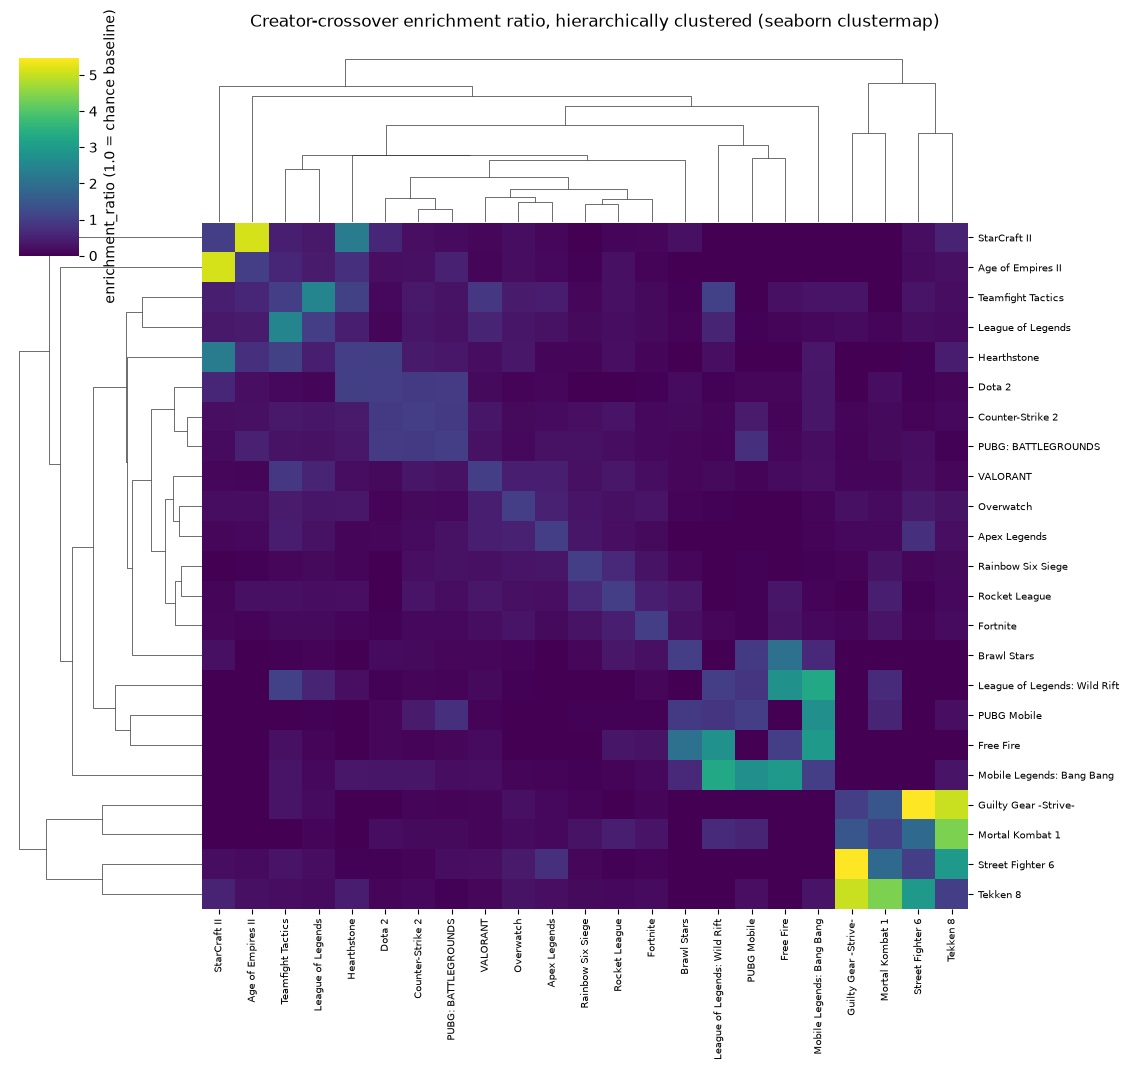

In [11]:
import seaborn as sns

g = sns.clustermap(
    enrichment_matrix,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    cmap="viridis",
    vmin=0,
    figsize=(12, 11),
    cbar_kws={"label": "enrichment_ratio (1.0 = chance baseline)"},
    xticklabels=True,
    yticklabels=True,
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize=7, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=7, rotation=0)
g.fig.suptitle("Creator-crossover enrichment ratio, hierarchically clustered (seaborn clustermap)", y=1.02)
g.savefig(Path.cwd() / "_creator_crossover_fig2_heatmap_seaborn.png", dpi=110)
plt.show()

### Read

**Updated 2026-10-02 — the strongest pair in the matrix changed hands.**

**Blocks, not a smooth gradient — the clustering surfaces real sub-
groups.** Two tight, high-enrichment blocks stand out: the four fighting
games (Tekken/Street Fighter/Guilty Gear/Mortal Kombat, enrichment now up
to 5.5x chance, versus 3.3x in the 09-15 pass) and the mobile MOBA/
battle-royale cluster (PUBG Mobile/Wild Rift/Mobile Legends, 2.7-3.3x).
League of Legends and Teamfight Tactics (both Riot titles sharing a
client) sit adjacent — their shared cell is no longer merely "consistent
with" being near chance, it's now itself one of the brighter off-diagonal
cells in the whole matrix (2.50x), reflecting the reversal documented in
`§ What the chance-adjustment actually changed` above.

**The single strongest pair in the whole matrix is no longer Age of
Empires II/StarCraft II — it's Guilty Gear -Strive-/Street Fighter 6,
enrichment_ratio=5.48, p=3.4e-24, comfortably surviving Bonferroni
correction.** Age of Empires II/StarCraft II is still real and still
significant (5.12x, p=1.5e-05, now backed by 841 and 758 total channels
respectively — roughly double the 09-15 pass's sample, so this isn't a
small-sample artifact either time) but it's been overtaken now that
the fighting-game cluster has accumulated five weeks of data instead of
two. Both pairs tell the same kind of story — a tight, significant,
same-genre creator-overlap signal between titles that don't otherwise
resemble anything else in the dataset closely enough to join a larger
block — it's just no longer accurate to call the RTS pair uniquely
exceptional. Read a bright off-diagonal cell as the real signal
regardless of where the axis puts it or which specific pair currently
holds the top rank — that rank itself has already changed once.

## Ranking titles by creator insularity

A direct follow-up: which esports creator communities are least likely
to stream *any* other tracked title at all — in absolute terms, not the
chance-adjusted enrichment above. `insularity_rate_pct` is simply the
share of a title's own above-threshold channels that never crossed over
to a second title this window; `mean_enrichment_vs_all_others` (the
enrichment matrix's row mean, excluding the diagonal) is shown alongside
as the chance-adjusted context — a title can be insular just because its
pool is tiny (mechanically fewer crossover opportunities), and that
distinction matters here the same way it did for the VALORANT/CS
`avg_channels` correction elsewhere in this project.

In [12]:
insularity_rows = []
for title_id in titles:
    name = display_name_by_id[title_id]
    total = int(total_channels_by_title.get(title_id, 0))
    crossover_for_title = channel_title_df[
        (channel_title_df["title_id"] == title_id)
        & (channel_title_df["channel_id"].isin(crossover_channel_ids))
    ]["channel_id"].nunique()
    non_crossover = total - crossover_for_title
    mean_enrichment_vs_others = enrichment_matrix.loc[name].drop(name).mean()
    insularity_rows.append({
        "title_id": title_id,
        "display_name": name,
        "total_channels": total,
        "crossover_channels": crossover_for_title,
        "insularity_rate_pct": round(non_crossover / total * 100, 1) if total else float("nan"),
        "mean_enrichment_vs_all_others": round(mean_enrichment_vs_others, 2),
    })

insularity_df = pd.DataFrame(insularity_rows).sort_values("insularity_rate_pct", ascending=False).reset_index(drop=True)
insularity_df

,title_id,display_name,total_channels,crossover_channels,insularity_rate_pct,mean_enrichment_vs_all_others
0,pubg_mobile,PUBG Mobile,920,88,90.4,0.31
1,brawl_stars,Brawl Stars,1734,192,88.9,0.23
2,free_fire,Free Fire,424,56,86.8,0.41
3,fortnite,Fortnite,65085,8976,86.2,0.16
4,wild_rift,League of Legends: Wild Rift,766,109,85.8,0.44
5,mobile_legends_bb,Mobile Legends: Bang Bang,1418,217,84.7,0.54
6,dota2,Dota 2,13599,2201,83.8,0.24
7,age_of_empires_ii,Age of Empires II,841,136,83.8,0.40
8,starcraft2,StarCraft II,758,125,83.5,0.48
9,tekken,Tekken 8,3007,543,81.9,0.71


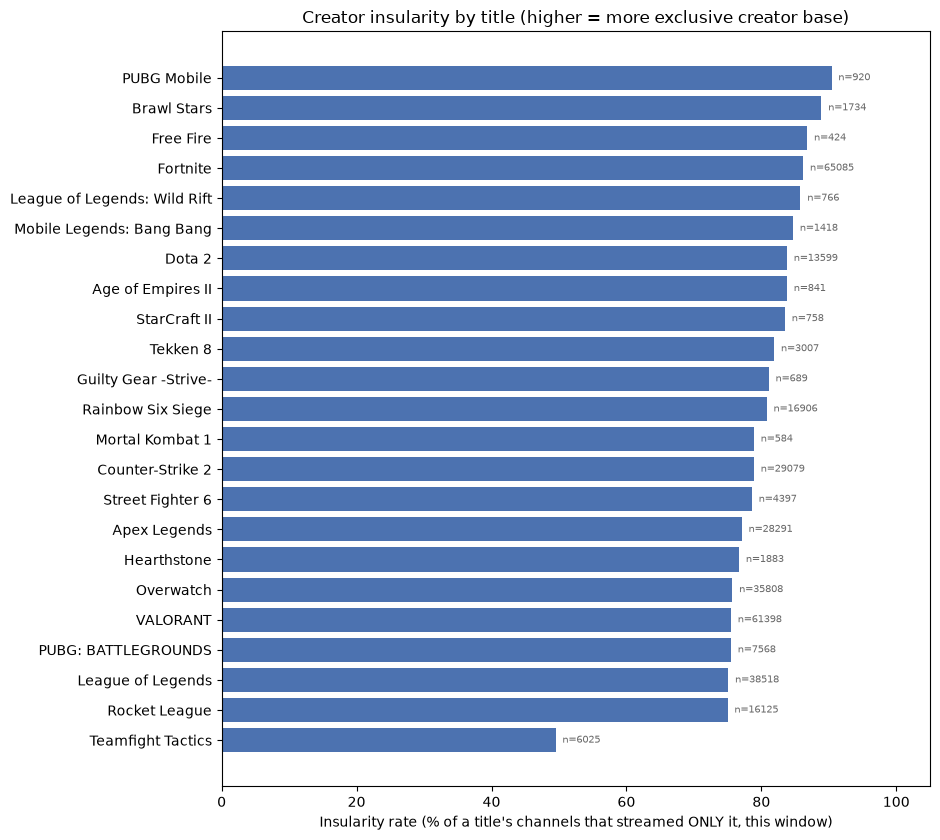

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 8.5))
plot_df = insularity_df.sort_values("insularity_rate_pct")
bars = ax.barh(plot_df["display_name"], plot_df["insularity_rate_pct"], color="#4c72b0")
ax.set_xlabel("Insularity rate (% of a title's channels that streamed ONLY it, this window)")
ax.set_title("Creator insularity by title (higher = more exclusive creator base)")
ax.set_xlim(0, 105)
for bar, total in zip(bars, plot_df["total_channels"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"n={total}", va="center", fontsize=7, color="dimgray")
plt.tight_layout()
plt.savefig(Path.cwd() / "_creator_crossover_fig3_insularity.png", dpi=110)
plt.show()

### Read

**Updated 2026-10-02 — the "every title is majority-insular" headline no
longer holds for all 23.**

**All but one tracked title is still majority-insular — Teamfight
Tactics has now crossed below the 50% line.** The 09-15 pass found a
64.1% floor ("roughly 20 points below every other title"); with five
weeks of data TFT has dropped to 49.5% — the only title whose creators
are now more likely than not to have crossed over to something else,
specifically League of Legends (see `§ What the chance-adjustment
actually changed` above). The next-lowest title, Rocket League at 75.0%,
hasn't moved nearly as much — so the gap between TFT and everything else
has actually widened (25.5 points now, versus ~20 before), even as TFT
itself crossed a qualitatively different line.

**PUBG Mobile ranks most insular in raw terms (90.4%, down slightly from
95.1%) — and it still holds up chance-adjusted.** Its
`mean_enrichment_vs_all_others` is 0.31 (up from 0.19, but still well
below the 1.0 chance baseline), so this remains a genuinely
below-chance-crossover creator base, not just "too few channels to have
crossed over yet" — its pool has nearly doubled (533 → 920) without the
qualitative read changing.

**Tekken is now the cleanest example of why `mean_enrichment` shouldn't
be read at face value — not Age of Empires II/StarCraft II anymore.**
Tekken shows a high insularity rate (81.9%) *and* the single highest
`mean_enrichment_vs_all_others` of any title (0.71), which looks
contradictory until you recall that the fighting-game cluster's own
tight, mutual enrichment (up to 5.5x, see the heatmap `§ Read` above) can
drag a title's average up even while the rest of its creator base stays
exclusive. Age of Empires II and StarCraft II no longer illustrate this
as sharply as they used to — their `mean_enrichment_vs_all_others` (0.40
and 0.48) has fallen out of the top two entirely, overtaken by Tekken
(0.71), Guilty Gear -Strive- (0.59), Street Fighter 6 (0.59), and Mortal
Kombat 1 (0.49) — the whole fighting-game block pulling its own averages
up together, not a single exceptional pair the way AoE2/StarCraft II
was framed before. Check the underlying pairs before reading any title's
mean as "this title's creators cross over a lot."

## Caveats

- **Creator crossover, not viewer overlap — restated, not a footnote.**
  Nothing above measures whether the same viewers watch two titles. A
  streamer appearing above-threshold for two titles says that streamer's
  own audience followed them across both at that moment; it doesn't say
  anything about the other 999 viewers of either title who never saw the
  other one. Treat this as a lower bound on *some* cross-title audience
  movement, driven by creators, not as a measure of overlap between the
  titles' audiences as a whole.
- **The hypergeometric null model assumes a channel's title choices are
  independent draws from the whole channel pool** — a simplification, not
  a claim that streaming is actually random. It's the standard reference
  point for "is this more than sampling noise," not a model of why a
  streamer picks the games they pick. A high enrichment ratio with a tiny
  p-value says the overlap is unlikely to be a coincidence of pool sizes;
  it doesn't by itself say *why* (shared genre, shared publisher/client
  like League/TFT, shared scheduling, shared org).
- **209 simultaneous hypergeometric tests is a real multiple-comparisons
  problem** — the printed counts above show both the raw p<0.05 tally and
  how many survive a Bonferroni correction; treat the gap between those
  two numbers as the honest read of how many pairs are likely real versus
  expected false positives, not the raw count alone.
- **This is five weeks of data, not a settled base rate — and the
  2026-10-02 re-run already demonstrated exactly how much that matters.**
  The above-threshold cutoff means a channel needs a real audience spike
  to register for a second title at all — plenty of genuine crossover
  streamers (who play both games regularly but at modest, below-threshold
  audience for one of them) won't show up yet, or ever, under this
  method. Going from 15 to 32 days of data flipped the League/Teamfight
  Tactics pair from "at chance" to one of the stronger enriched pairs in
  the dataset, and swapped which pair holds the single-strongest-in-the-
  matrix rank. Re-run again as `viewership_snapshots` accumulates further;
  don't treat today's channel counts, enrichment ratios, or p-values as
  final — small `total_channels_a`/`b` denominators still mean a handful
  of new crossover streams next week could swing a ratio substantially,
  and this run just showed that isn't a hypothetical.
- **`is_official_broadcast` now does real exclusion work for 5 of 23
  titles** (counter_strike, dota2, street_fighter, valorant, pubg, per
  `config/channels.yaml`), still a no-op for the other 18 until they're
  curated too. For those five, this notebook's crossover counts no longer
  include their large media-org/tournament-broadcast channels — a
  different phenomenon than an individual creator crossing over — but
  that exclusion doesn't yet apply uniformly across all 23 titles, so a
  pair involving one curated and one uncurated title is comparing a
  filtered pool against an unfiltered one. Worth rechecking once more
  titles are curated.
- **A channel_id is a Twitch account, not necessarily one person** — some
  crossover channels here may be multi-game variety orgs, co-streaming
  services, or rebroadcast channels rather than a single creator. Worth a
  manual look at the top of the per-channel table before treating any
  individual name as a "this creator bridges these two fandoms" finding.